## Insight 1: NAV Trend

The daily NAV of most mutual fund schemes showed a consistent upward trend from 2022 to 2025. A strong growth phase was observed during the 2023 bull market, while growth moderated during the 2024 market correction.

**Supporting Chart:** Figure 1 – Daily NAV Trend Analysis

## Insight 2: Assets Under Management (AUM)

SBI Mutual Fund maintained the highest Assets Under Management (AUM) among all fund houses and reached approximately ₹12.5 lakh crore by 2025, demonstrating its market leadership.

**Supporting Chart:** Figure 2 – AUM Growth by Fund House

## Insight 3: SIP Inflows

Monthly SIP inflows steadily increased throughout the analysis period and reached an all-time high in December 2025, indicating growing investor confidence and increasing retail participation.

**Supporting Chart:** Figure 3 – Monthly SIP Inflow Trend

## Insight 4: Category-wise Inflows

Liquid Funds consistently attracted the highest monthly net inflows compared to other mutual fund categories, reflecting investors' preference for low-risk and highly liquid investments.

**Supporting Chart:** Figure 4 – Category Inflow Heatmap

## Insight 5: Investor Age Distribution

Investors aged 26–35 formed the largest investor segment, accounting for approximately 41% of the total investor base.

**Supporting Chart:** Figure 5 – Age Group Distribution

## Insight 6: Gender Distribution

Male investors accounted for approximately two-thirds of the investor population, while female investors represented about one-third.

**Supporting Chart:** Figure 6 – Gender Distribution

## Insight 7: Geographic Distribution

States such as Punjab, Tamil Nadu, and Madhya Pradesh recorded the highest cumulative investment amounts, indicating strong regional participation in mutual fund investments.

**Supporting Chart:** Figure 7 – State-wise Investment Distribution

## Insight 8: Mutual Fund Folios

The total number of mutual fund folios showed continuous growth from 2022 to 2025, reflecting increasing investor participation in the mutual fund industry.

**Supporting Chart:** Figure 8 – Folio Count Growth

## Insight 9: NAV Return Correlation

Most selected equity mutual funds exhibited a positive correlation in daily NAV returns, indicating that they generally moved in the same direction under similar market conditions.

**Supporting Chart:** Figure 9 – NAV Return Correlation Matrix

## Insight 10: Sector Allocation

Portfolio allocations were concentrated in a few major sectors, highlighting sector-specific investment strategies across equity mutual funds.

**Supporting Chart:** Figure 10 – Sector Allocation Donut Chart

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from pathlib import Path

data_path = Path("../data")

print("Raw files:")
for file in (data_path / "raw").glob("*"):
    print("-", file.name)

print("\nProcessed files:")
for file in (data_path / "processed").glob("*"):
    print("-", file.name)

Raw files:
- 01_fund_master.csv
- 02_nav_history.csv
- 03_aum_by_fund_house.csv
- 04_monthly_sip_inflows.csv
- 05_category_inflows.csv
- 06_industry_folio_count.csv
- 07_scheme_performance.csv
- 08_investor_transactions.csv
- 09_portfolio_holdings.csv
- 10_benchmark_indices.csv
- Axis_Bluechip.csv
- hdfc_top100_live_nav.csv
- ICICI_Bluechip.csv
- Kotak_Bluechip.csv
- Nippon_LargeCap.csv
- SBI_Bluechip.csv

Processed files:
- 02_nav_history_clean.csv
- 07_scheme_performance_clean.csv
- 08_investor_transactions_clean.csv


In [9]:
# Load datasets

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully!")


All datasets loaded successfully!


In [8]:
datasets = {
    "Fund Master": fund_master,
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Fund Master: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Portfolio: (322, 8)
Benchmark: (8050, 3)


In [6]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [7]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


In [8]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'], dtype='object')


In [9]:
print(category.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='object')


In [10]:
print(transactions.columns)


Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status'], dtype='object')


In [11]:
# Merge NAV data with fund names

nav_merged = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav_merged.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [12]:
fig = px.line(
    nav_merged,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    legend_title="Scheme Name",
    height=700
)

fig.show()

In [13]:
print(fund_master.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code'], dtype='object')


In [14]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [15]:
aum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     object 
 1   fund_house      90 non-null     object 
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3.6+ KB


In [16]:
print(aum["date"].head())

0    2022-03-31
1    2022-03-31
2    2022-03-31
3    2022-03-31
4    2022-03-31
Name: date, dtype: object


In [17]:
# Convert date to datetime (if not already)
aum["date"] = pd.to_datetime(aum["date"])

# Create year column
aum["year"] = aum["date"].dt.year

# Keep only 2022–2025
aum_plot = aum[aum["year"].between(2022, 2025)]

aum_plot.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


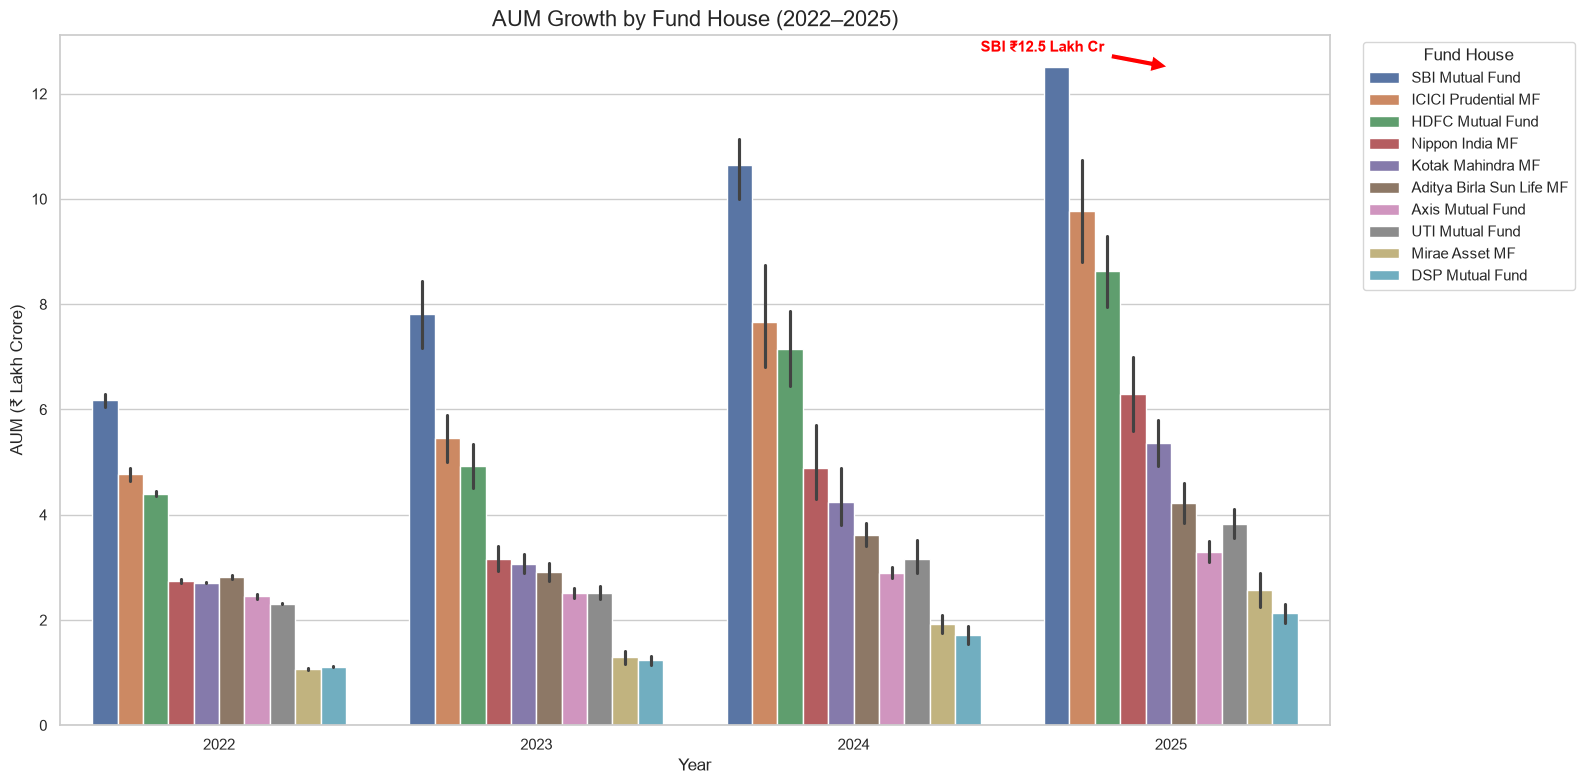

In [19]:
plt.figure(figsize=(16, 8))

sns.barplot(
    data=aum_plot,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

# Highlight SBI dominance
plt.annotate(
    "SBI ₹12.5 Lakh Cr",
    xy=(3, 12.5),
    xytext=(2.4, 12.8),
    arrowprops=dict(facecolor="red", shrink=0.05),
    fontsize=11,
    color="red",
    fontweight="bold"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Fund House"
)

plt.tight_layout()

plt.savefig(
    "../reports/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [21]:
sip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     object 
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 2.4+ KB


In [6]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    template="plotly_white"
)

# Highlight the all-time high
fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr (All-Time High)",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    height=600,
    width=1100
)

fig.show()

In [10]:
fig.write_image("../reports/sip_trend.png")

Resorting to unclean kill browser.


RuntimeError: Couldn't close or kill browser subprocess

In [1]:
import sys
print(sys.executable)

c:\Users\NEW\OneDrive\Desktop\MutualFundProject\venv\Scripts\python.exe


In [2]:
import plotly.io as pio

print(pio.get_chrome())

ValueError: 
This command requires Kaleido v1.0.0 or greater.
Install it using `pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`."


In [10]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [11]:
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [12]:
category["month"] = pd.to_datetime(category["month"])

category["month_name"] = category["month"].dt.strftime("%b-%Y")

In [15]:
# Sort by date first
category = category.sort_values("month")

# Create pivot table using actual datetime values
heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

# Convert datetime columns to readable labels
heatmap_data.columns = heatmap_data.columns.strftime("%b-%Y")

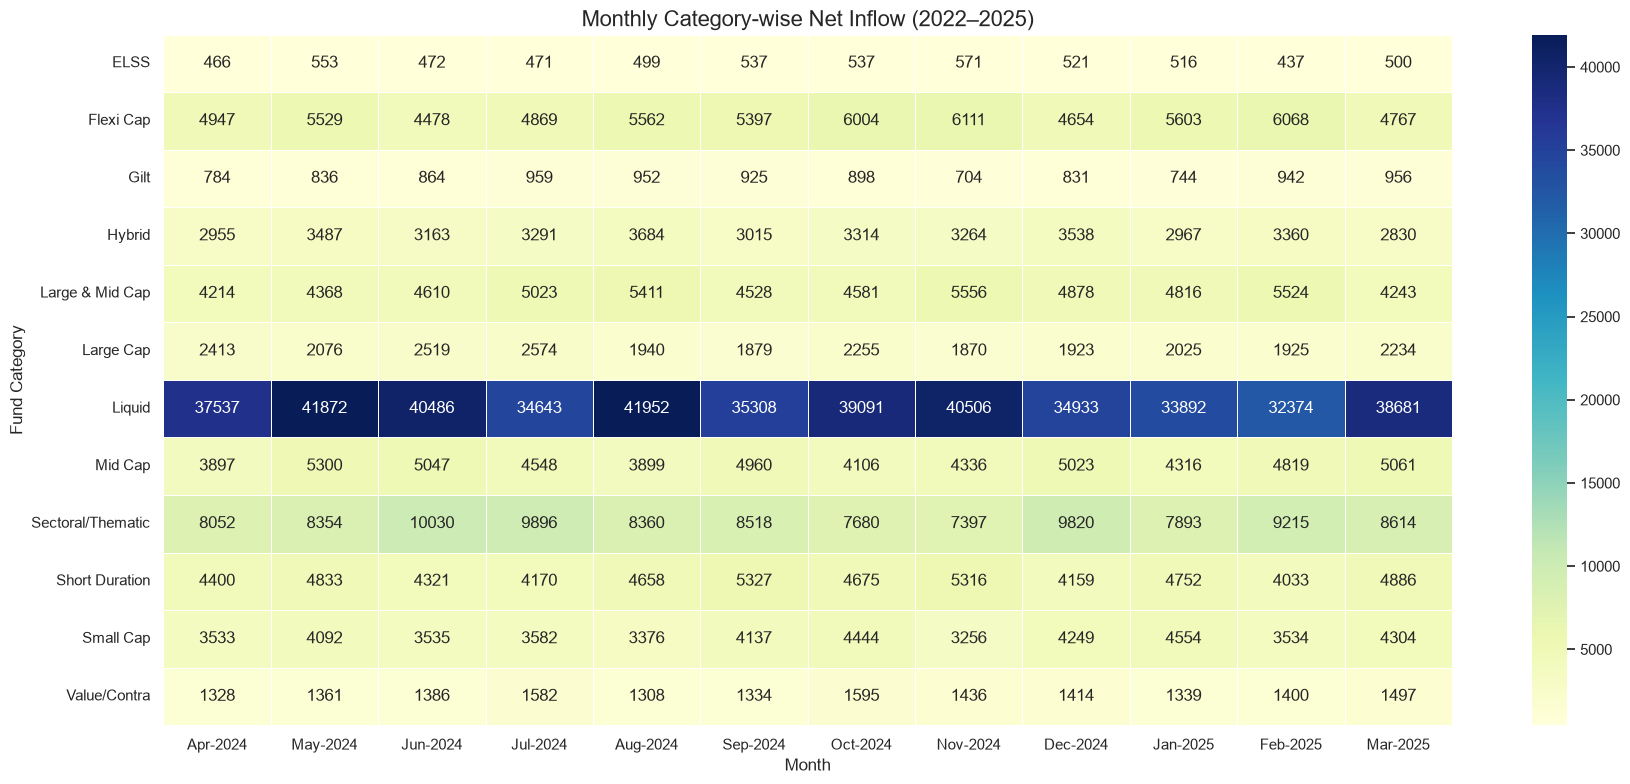

In [16]:
plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Monthly Category-wise Net Inflow (2022–2025)", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    "../reports/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status'], dtype='str')


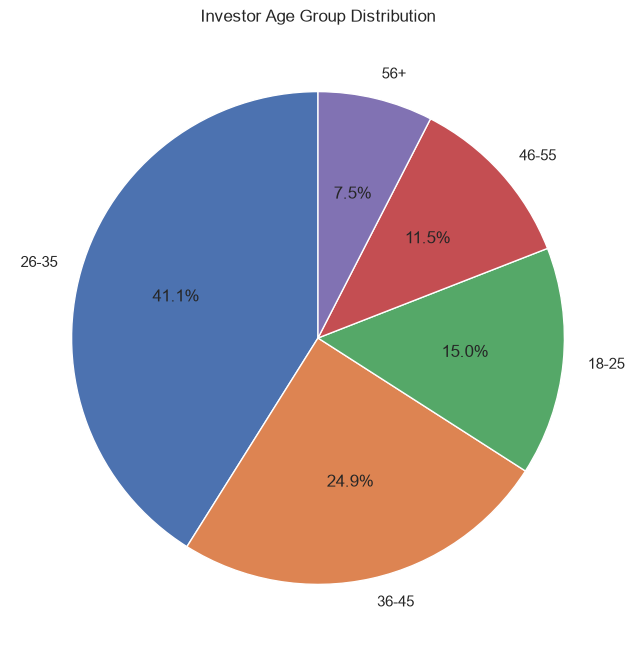

In [19]:
# Age Group Distribution

age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

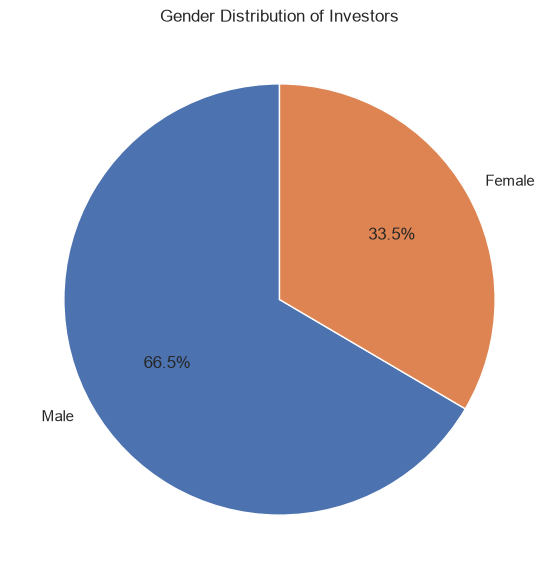

In [21]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.savefig(
    "../reports/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

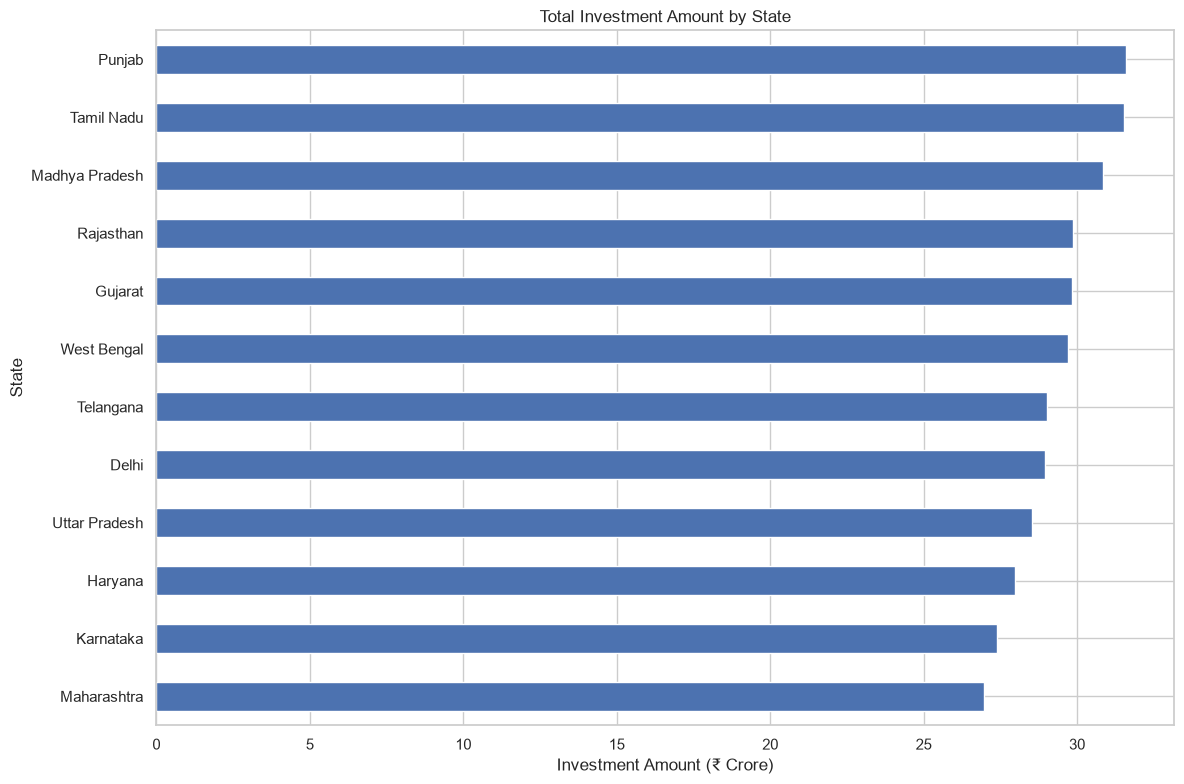

In [23]:
# Total investment amount by state
state_amount = (
    transactions.groupby("state")["amount_inr"]
    .sum() / 10000000   # Convert ₹ to Crore
).sort_values()

plt.figure(figsize=(12,8))

state_amount.plot(kind="barh")

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (₹ Crore)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/state_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

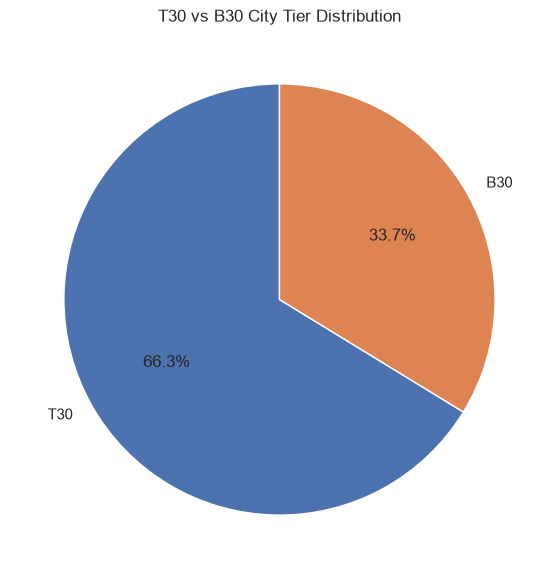

In [24]:
city_tier = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")

plt.savefig(
    "../reports/city_tier_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [26]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'], dtype='str')


In [27]:
# Convert month to datetime
folio["month"] = pd.to_datetime(folio["month"])

# Sort by month
folio = folio.sort_values("month")

In [28]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth in Mutual Fund Folios (2022–2025)",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Total Folios (Crore)",
    width=1200,
    height=600
)

fig.show()

In [30]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth in Mutual Fund Folios (2022–2025)",
    template="plotly_white"
)

# First milestone
fig.add_annotation(
    x=folio.iloc[0]["month"],
    y=folio.iloc[0]["total_folios_crore"],
    text=f"Start: {folio.iloc[0]['total_folios_crore']:.2f} Cr",
    showarrow=True,
    arrowhead=2
)

# Last milestone
fig.add_annotation(
    x=folio.iloc[-1]["month"],
    y=folio.iloc[-1]["total_folios_crore"],
    text=f"End: {folio.iloc[-1]['total_folios_crore']:.2f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Total Folios (Crore)",
    width=1200,
    height=600
)

fig.show()

In [32]:
# fig.write_image("../reports/folio_growth.png")

In [33]:
nav_corr = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [34]:
selected_funds = nav_corr["scheme_name"].unique()[:10]

corr_data = nav_corr[
    nav_corr["scheme_name"].isin(selected_funds)
]

In [35]:
corr_data = corr_data.sort_values(["scheme_name", "date"])

corr_data["daily_return"] = (
    corr_data
    .groupby("scheme_name")["nav"]
    .pct_change()
)

In [36]:
corr_matrix = corr_data.pivot_table(
    index="date",
    columns="scheme_name",
    values="daily_return"
)

In [37]:
corr = corr_matrix.corr()

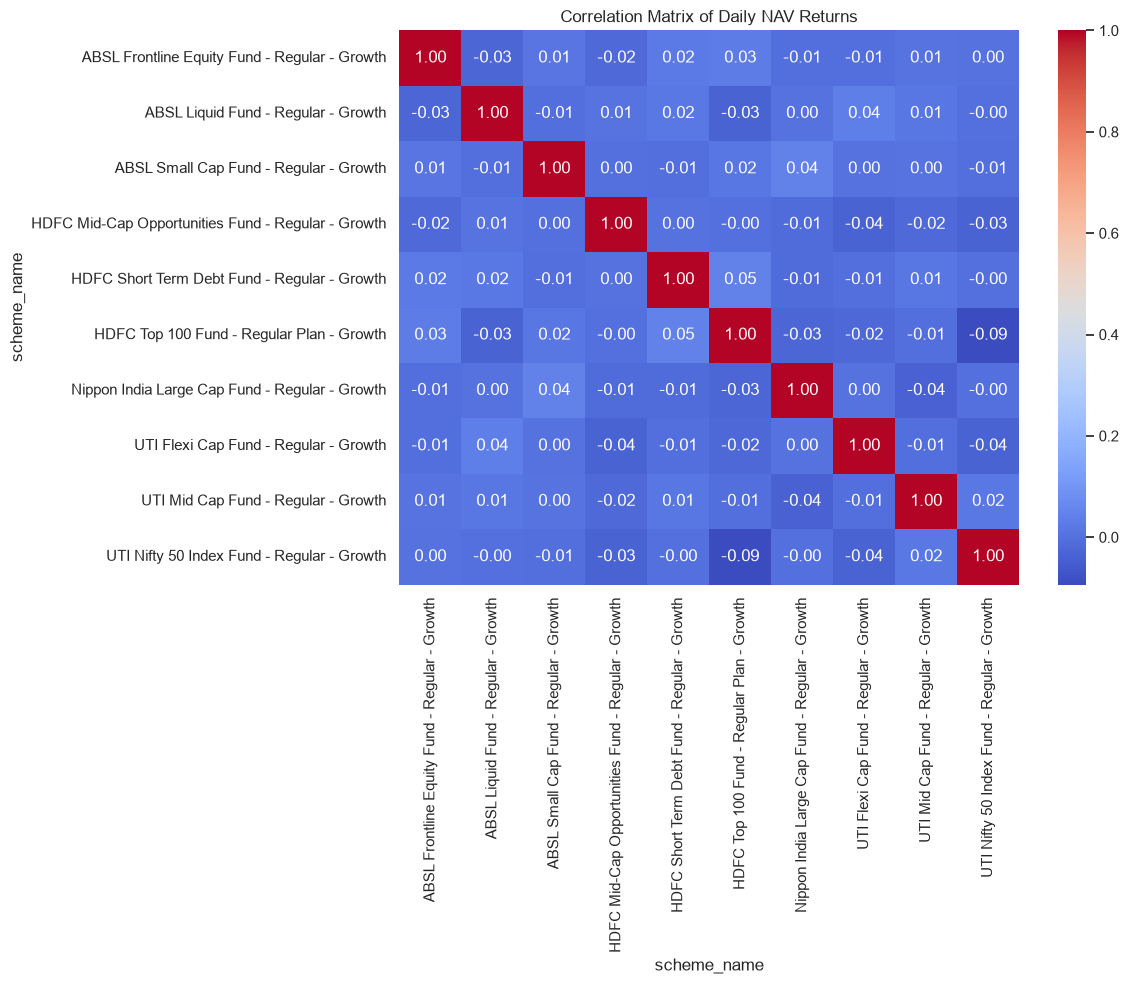

In [38]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.savefig(
    "../reports/nav_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [40]:
print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date'], dtype='str')


In [41]:
# Aggregate sector allocation

sector_data = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_data

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

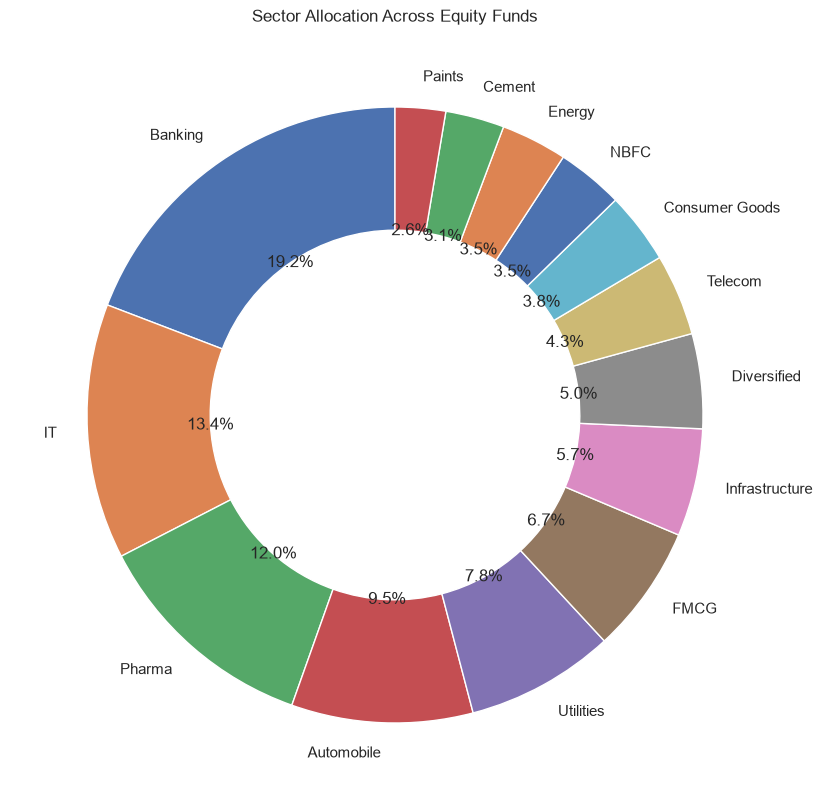

In [42]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)   # Makes it a donut
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig(
    "../reports/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()